In [1]:
!pip install ultralytics
!pip install roboflow


[notice] A new release of pip is available: 24.1 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.1 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!nvidia-smi

Wed Jun 26 13:51:48 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   40C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
#from google.colab import drive
import os
from ultralytics import YOLO
import random
from IPython.display import Image
from roboflow import Roboflow

Configure uma pasta do drive para salvar os arquivos.

In [3]:
#drive.mount('/content/drive')
#os.chdir('/content/drive/MyDrive/')
HOME = os.getcwd()

Baixa o dataset escolhido pelo grupo!

In [ ]:
rf = Roboflow(api_key="") #Use uma chave API do roboflow para baixar o dataset
project = rf.workspace("shahad-alotaibi-ujdrb").project("car-accident-severity")
version = project.version(1)
dataset = version.download("yolov8-obb")

## Treinamento

Todos os argumentos e hyperparâmetros do YOLO: https://docs.ultralytics.com/modes/train/#resuming-interrupted-trainings

In [ ]:
model = YOLO(model='yolov8n.pt')

result = model.train(
    data=f'{dataset.location}/data.yaml',  # Caminho para o arquivo de configuração do conjunto de dados
    epochs=20,  # Número total de épocas para treinar o modelo
    patience=0,  # O treinamento para caso não haja melhoria nos dados de validação (evita overfitting)
    batch=16,  # Tamanho do lote (número de imagens processadas por vez)
    imgsz=640,  # Tamanho das imagens usadas no treinamento
    workers=8,  # Quantidade de threads a serem usadas pela GPU (padrão é 8)
    pretrained=True,  # Utiliza pesos pré-treinados para inicializar o modelo
    resume=False,  # Continua o treinamento de um ponto de verificação salvo, se disponível
    single_cls=False,  # Se True, unifica todas as classes em uma só (útil para testar se há problemas com as classes)
    box=7.5,  # Hiperparâmetro de perda para caixas delimitadoras (bounding boxes)
    cls=0.5,  # Hiperparâmetro de perda para a classificação
    dfl=1.5,  # Hiperparâmetro de perda para distribuição (distribution focal loss)
    val=True,  # Validação após o final de cada época (importante para acompanhar a evolução do modelo, mas consome mais processamento da GPU)
    degrees=0.3,  # Grau de rotação para a augmentação dos dados
    hsv_s=0.3,  # Saturação para a augmentação HSV dos dados
    hsv_v=0.3,  # Valor para a augmentação HSV dos dados
    scale=0.5,  # Escala para a augmentação dos dados
    fliplr=0.5  # Probabilidade de flip horizontal para a augmentação dos dados
)

Ultralytics YOLOv8.2.43 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/Car-Accident-Severity-1/data.yaml, epochs=20, time=None, patience=0, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels

train: Scanning /content/drive/MyDrive/Car-Accident-Severity-1/train/labels... 5321 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5321/5321 [00:51<00:00, 103.89it/s]


train: New cache created: /content/drive/MyDrive/Car-Accident-Severity-1/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
val: Scanning /content/drive/MyDrive/Car-Accident-Severity-1/valid/labels... 998 images, 0 backgrounds, 0 corrupt: 100%|██████████| 998/998 [00:17<00:00, 56.28it/s] 


val: New cache created: /content/drive/MyDrive/Car-Accident-Severity-1/valid/labels.cache
Plotting labels to runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      20/20      2.29G     0.4119     0.2999     0.9176          9        640: 100%|██████████| 333/333 [02:41<00:00,  2.06it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:18<00:00,  1.73it/s]

                   all        998       1038      0.969      0.955      0.978      0.899



20 epochs completed in 1.021 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics YOLOv8.2.43 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3006038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:21<00:00,  1.49it/s]


                   all        998       1038      0.974      0.952      0.978      0.899
     accident moderate        257        261       0.96      0.927      0.969      0.874
       accident severe        746        777      0.988      0.977      0.988      0.924
Speed: 0.3ms preprocess, 2.7ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to runs/detect/train


## Avaliação do(s) modelo(s)

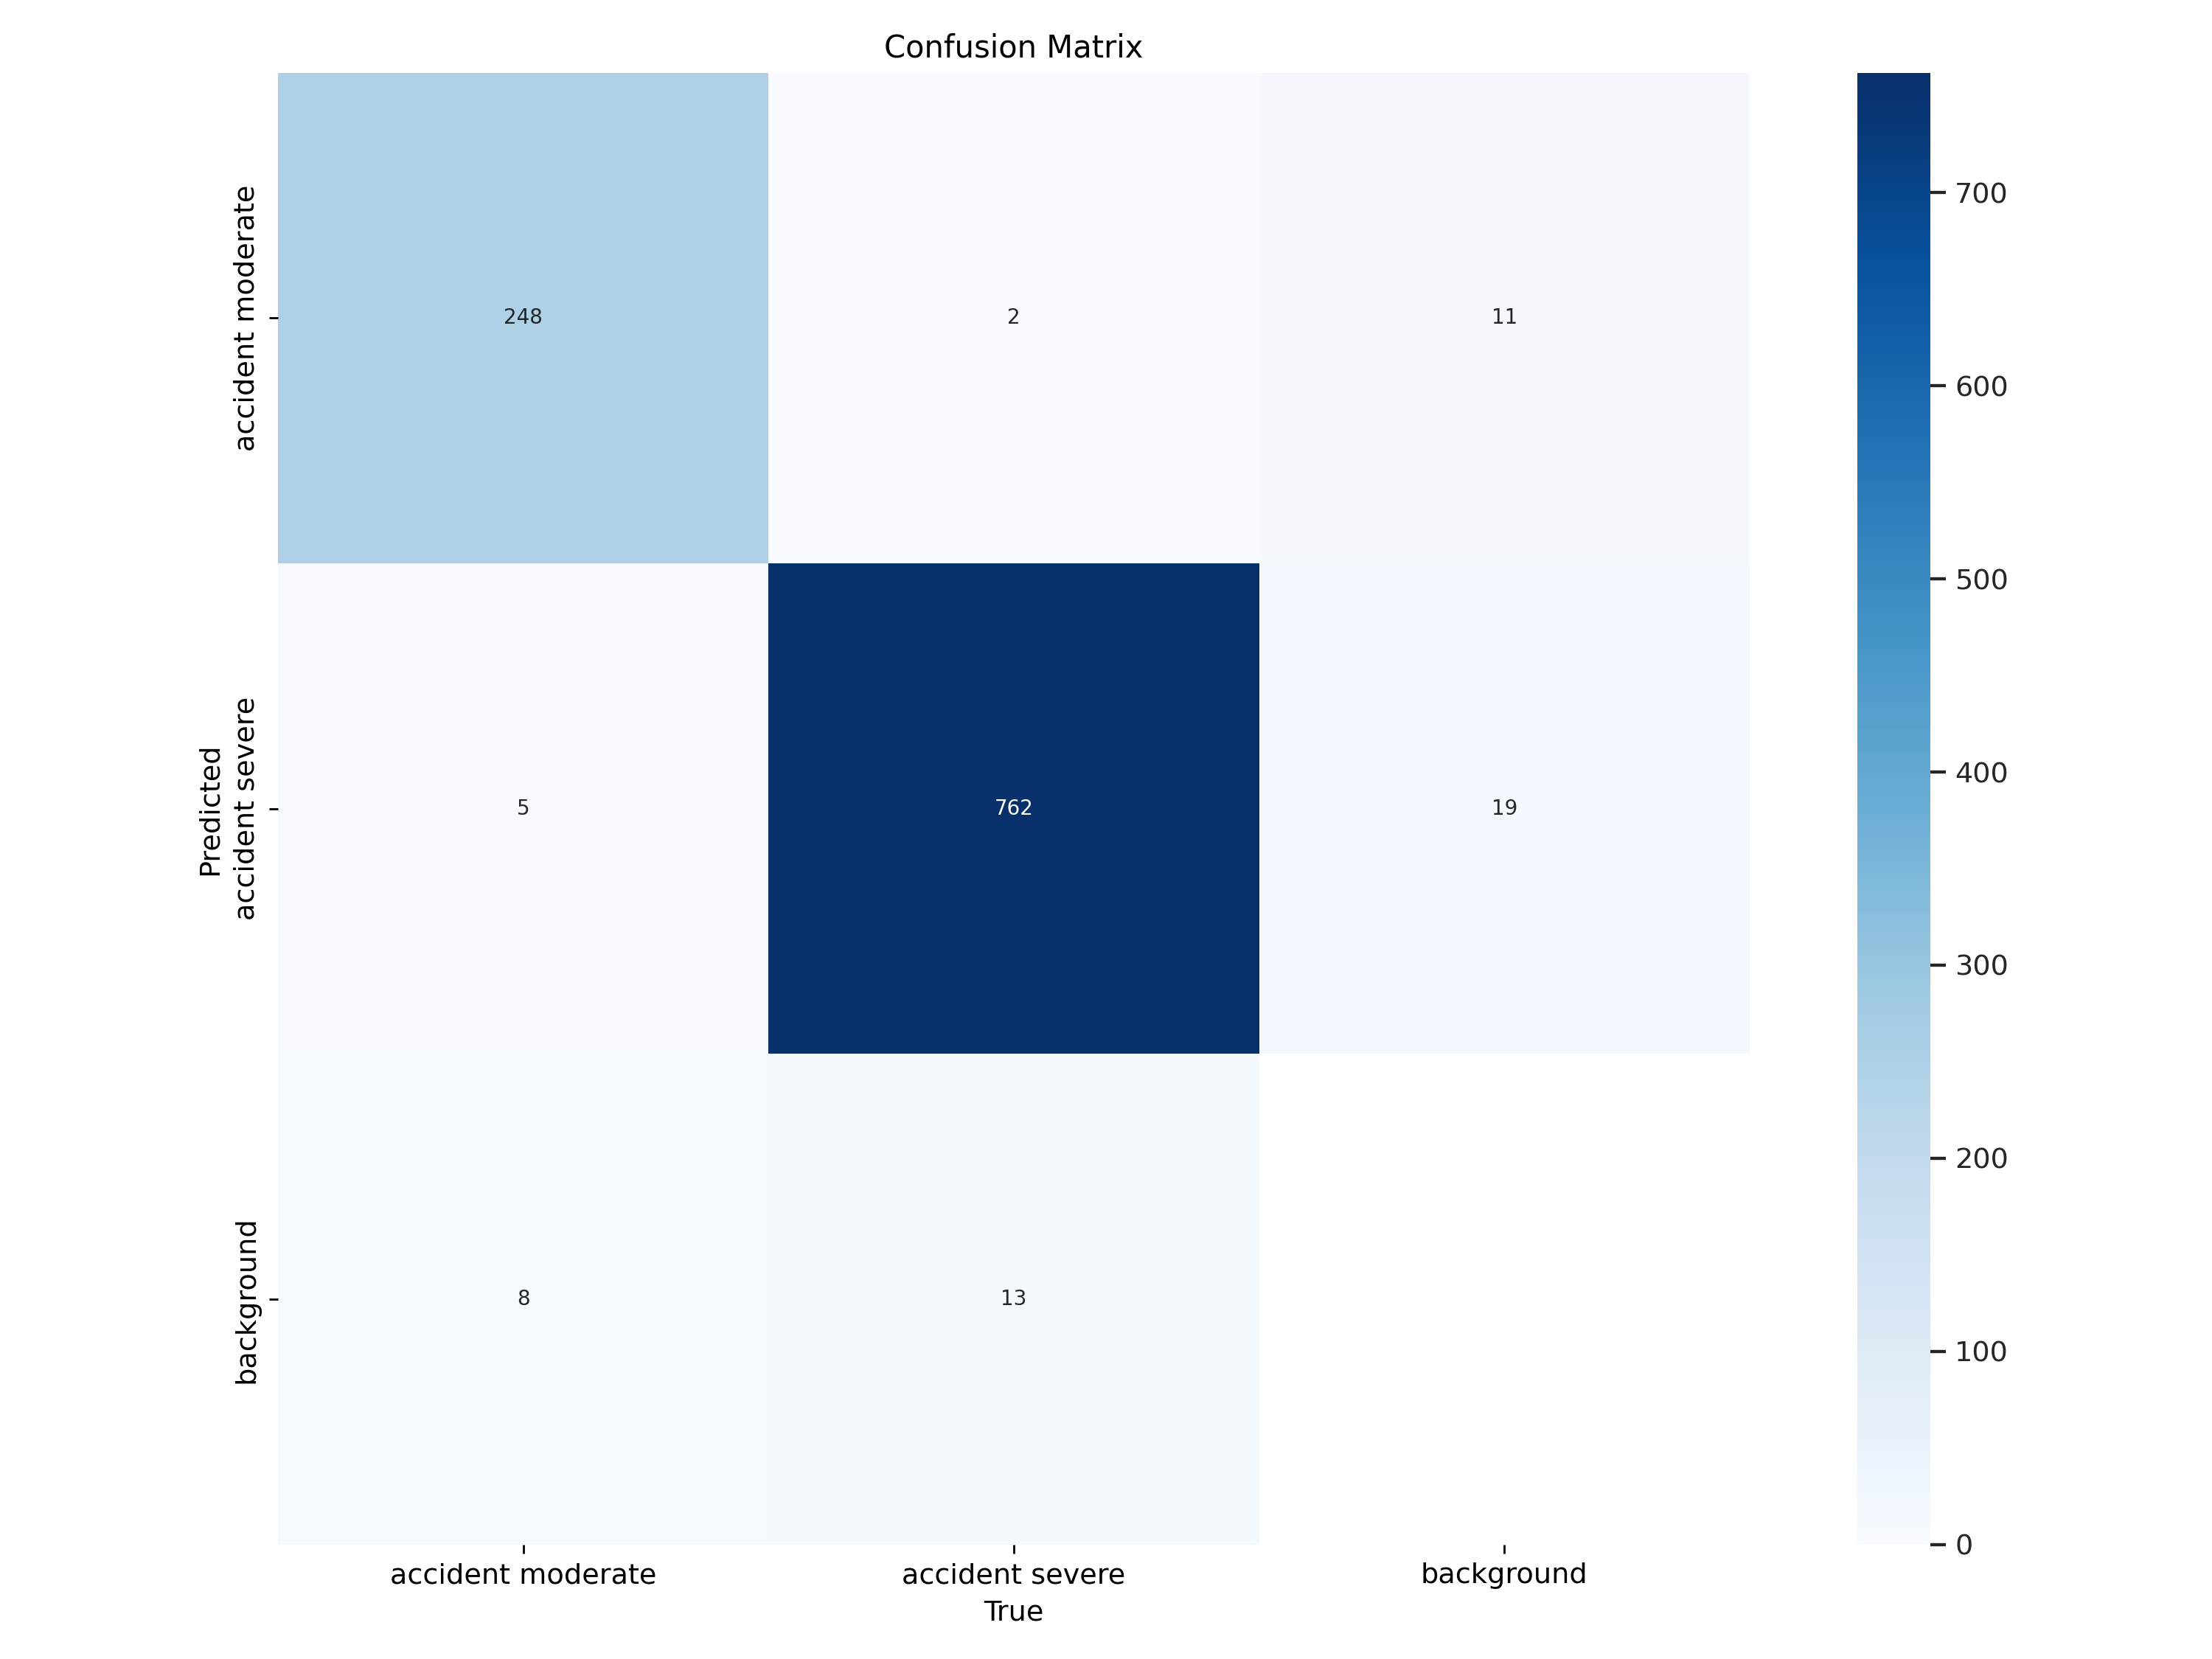

In [5]:
# Confusion-Matrix
Image(f'{HOME}/runs/detect/train-Detect-Accident/confusion_matrix.png', width=640)

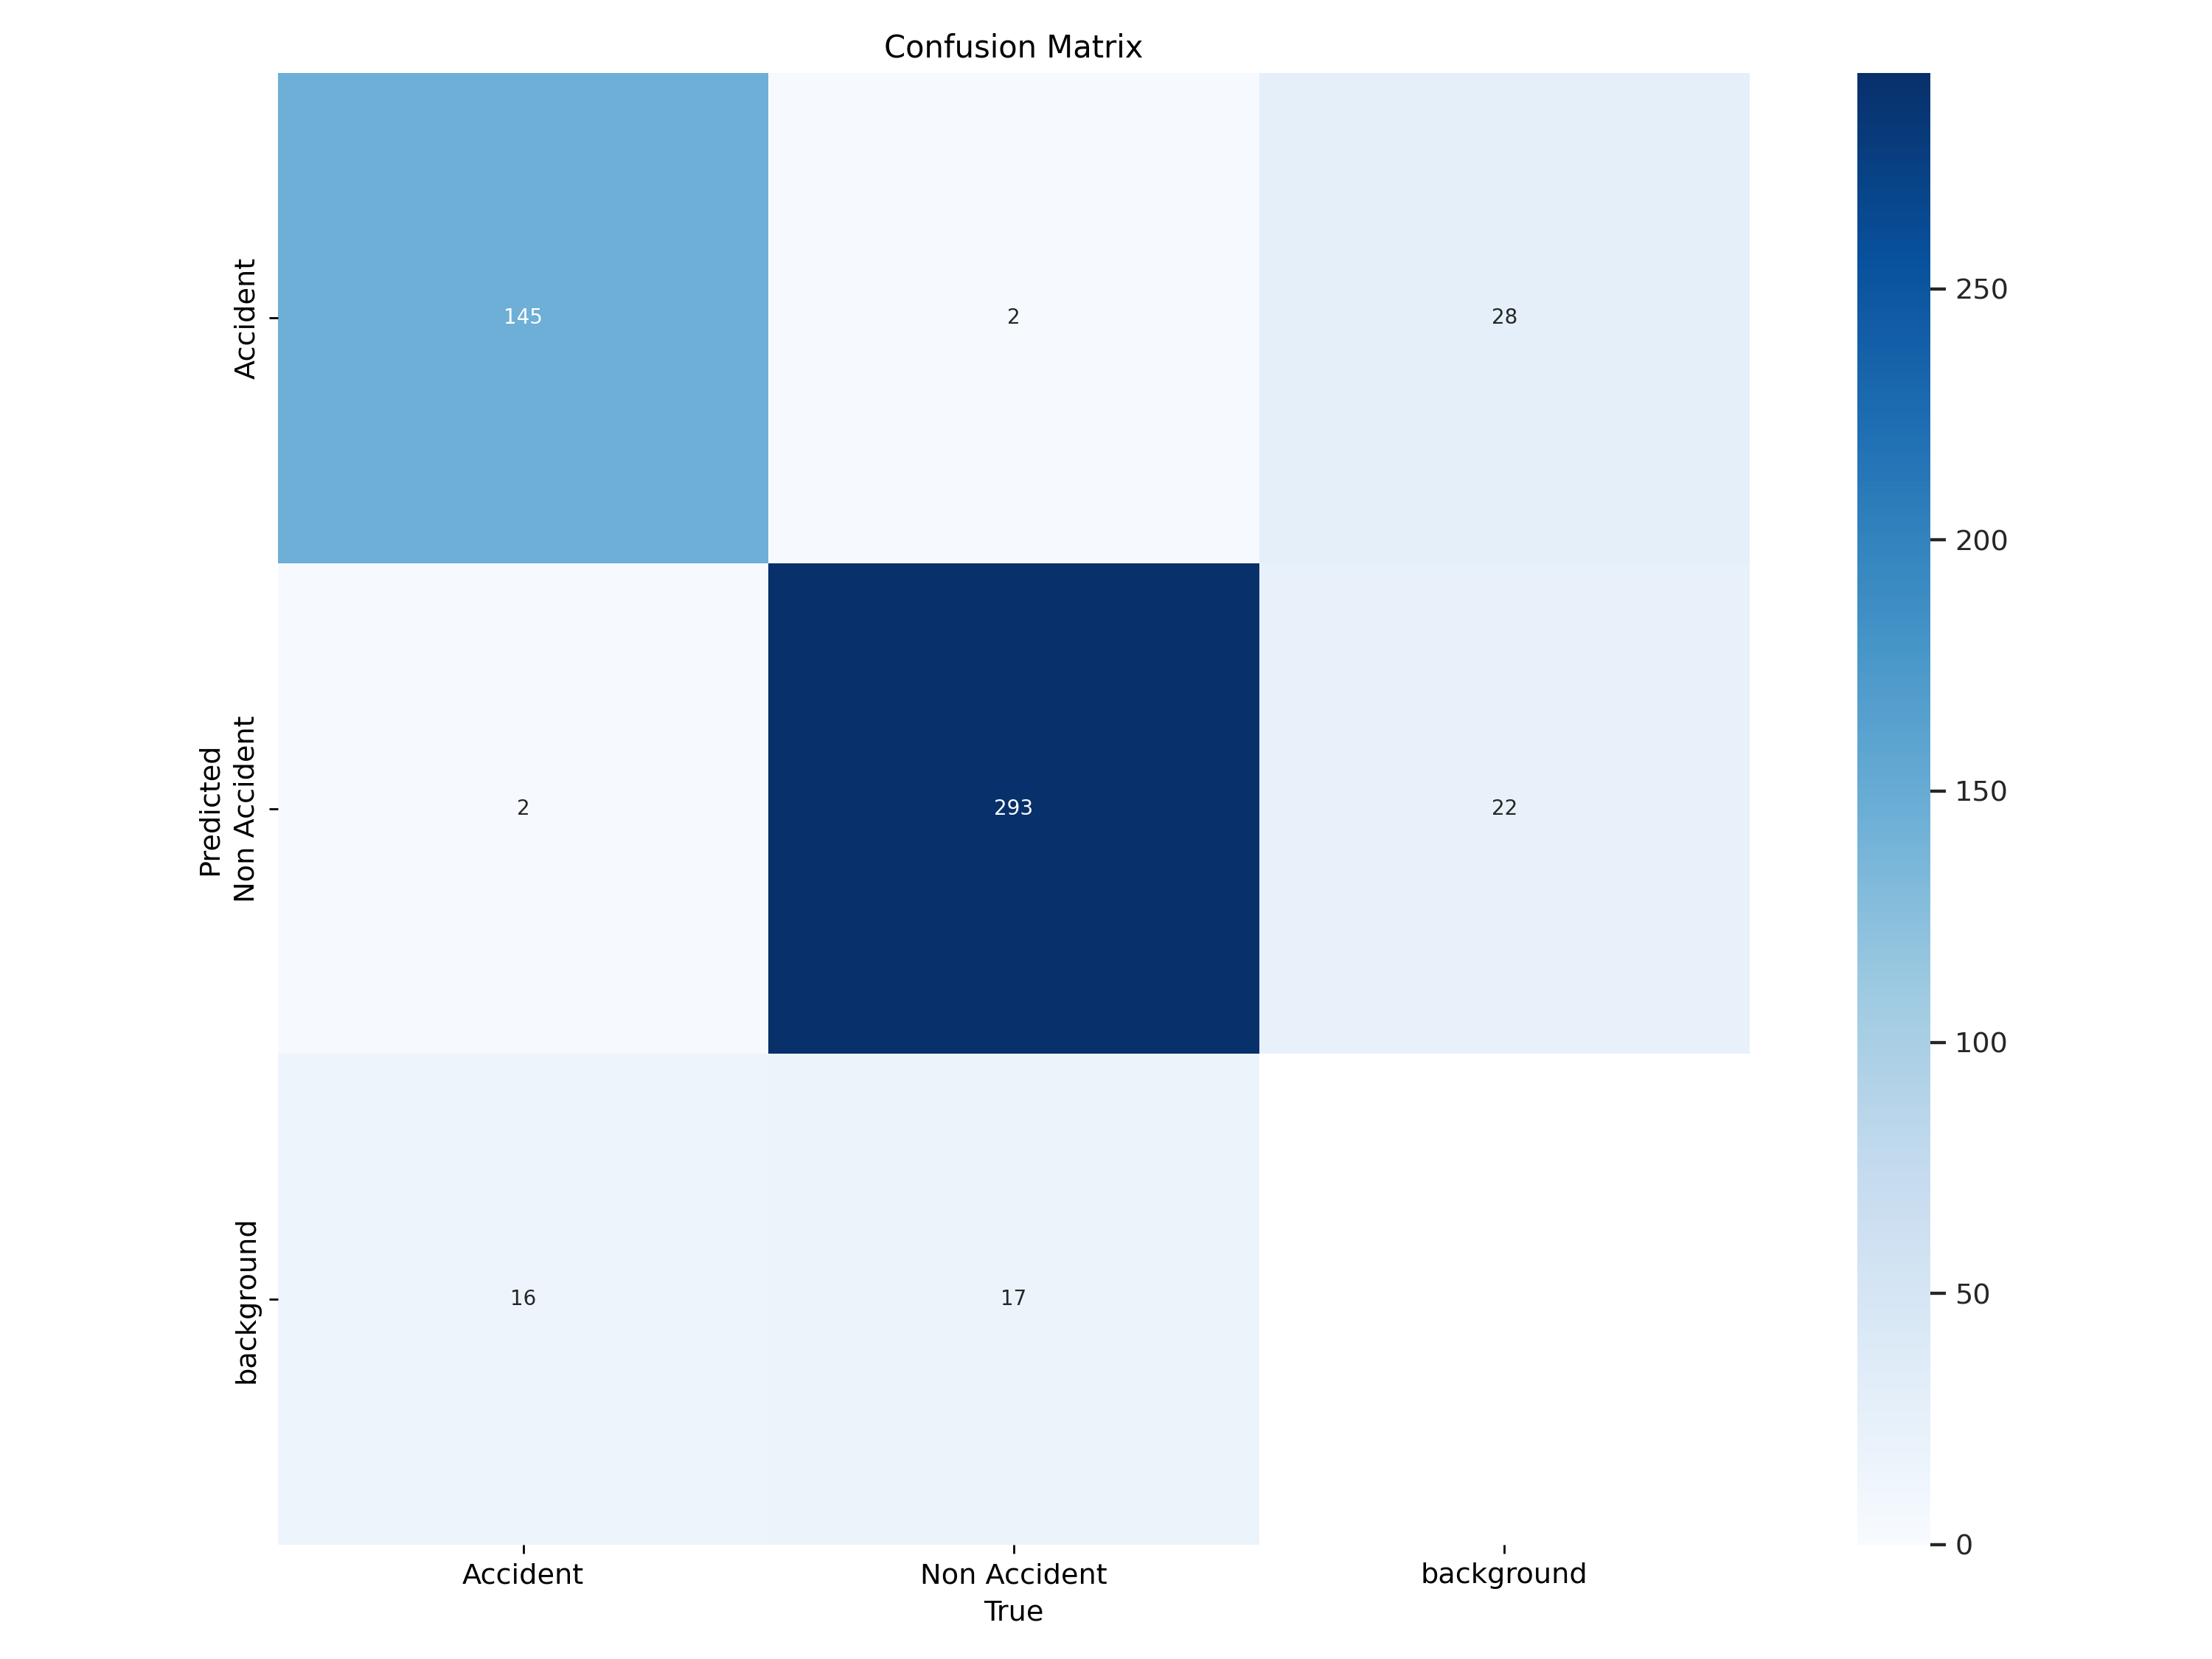

In [6]:
Image(f'{HOME}/runs/detect/train-Detect-Accident-Non-Accident-2/confusion_matrix.png', width=640)

Algumas métricas importantes:

- **metrics/mAP50(B):**
  representa a média de precisão (mAP) com um threshold de 0.50 durante a validação. Um aumento consistente no mAP50 indica que o modelo está melhorando na detecção de objetos nos dados de validação.
- **metrics/mAP50-95(B):** representa a média de precisão (mAP) em um
intervalo de thresholds de 0.50 a 0.95 durante a validação. Um aumento consistente no mAP50-95 indica que o modelo está melhorando em uma gama de diferentes thresholds de detecção


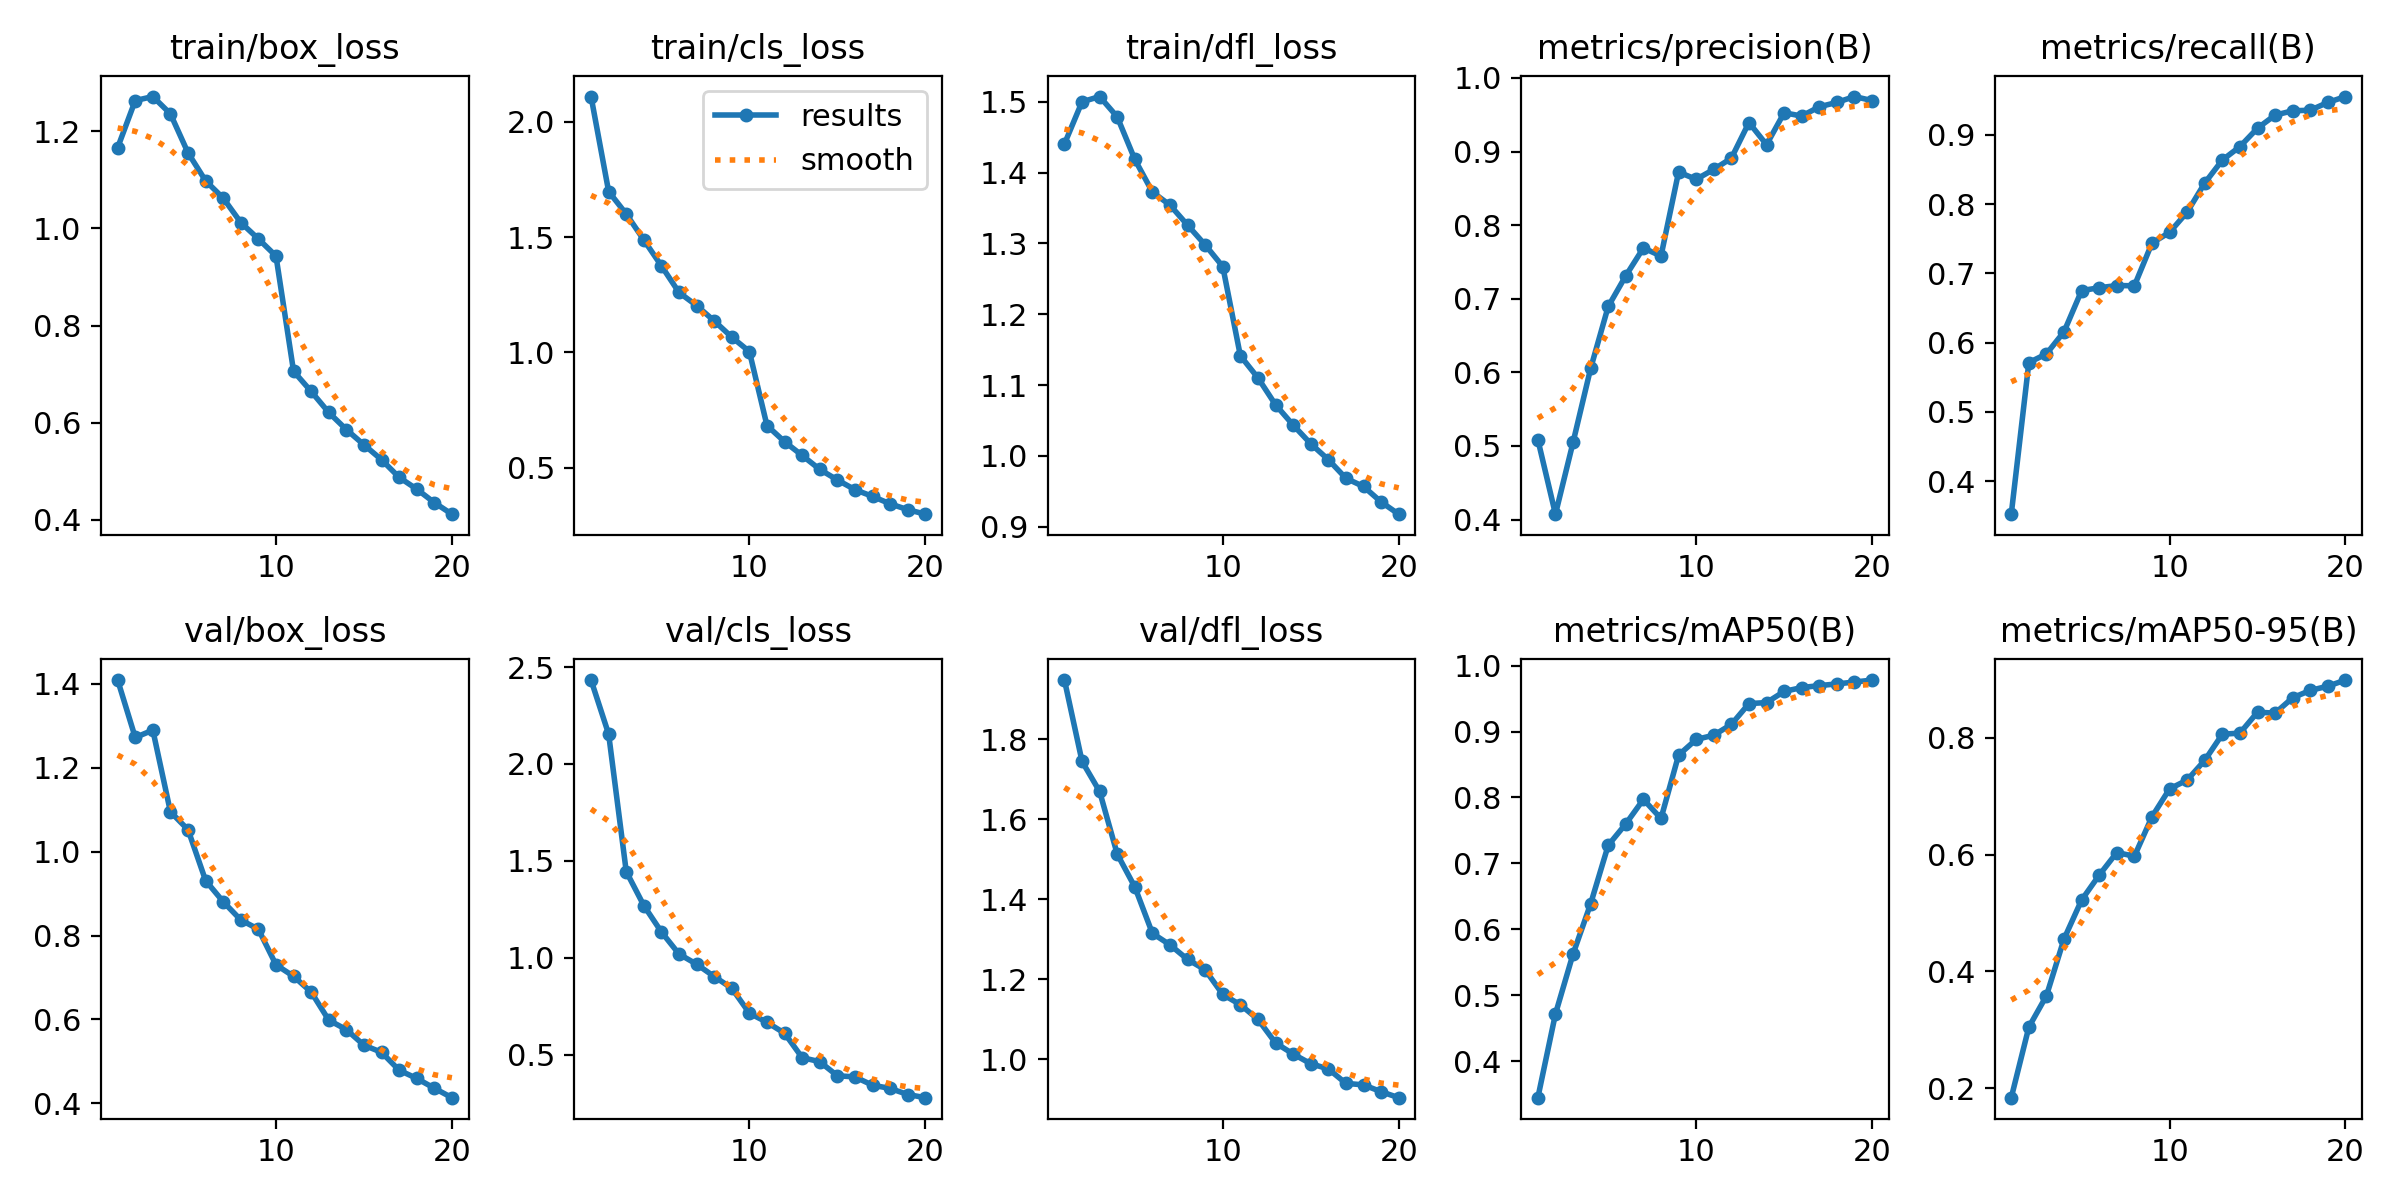

In [ ]:
Image(f'{HOME}/runs/detect/train/results.png', width=800)

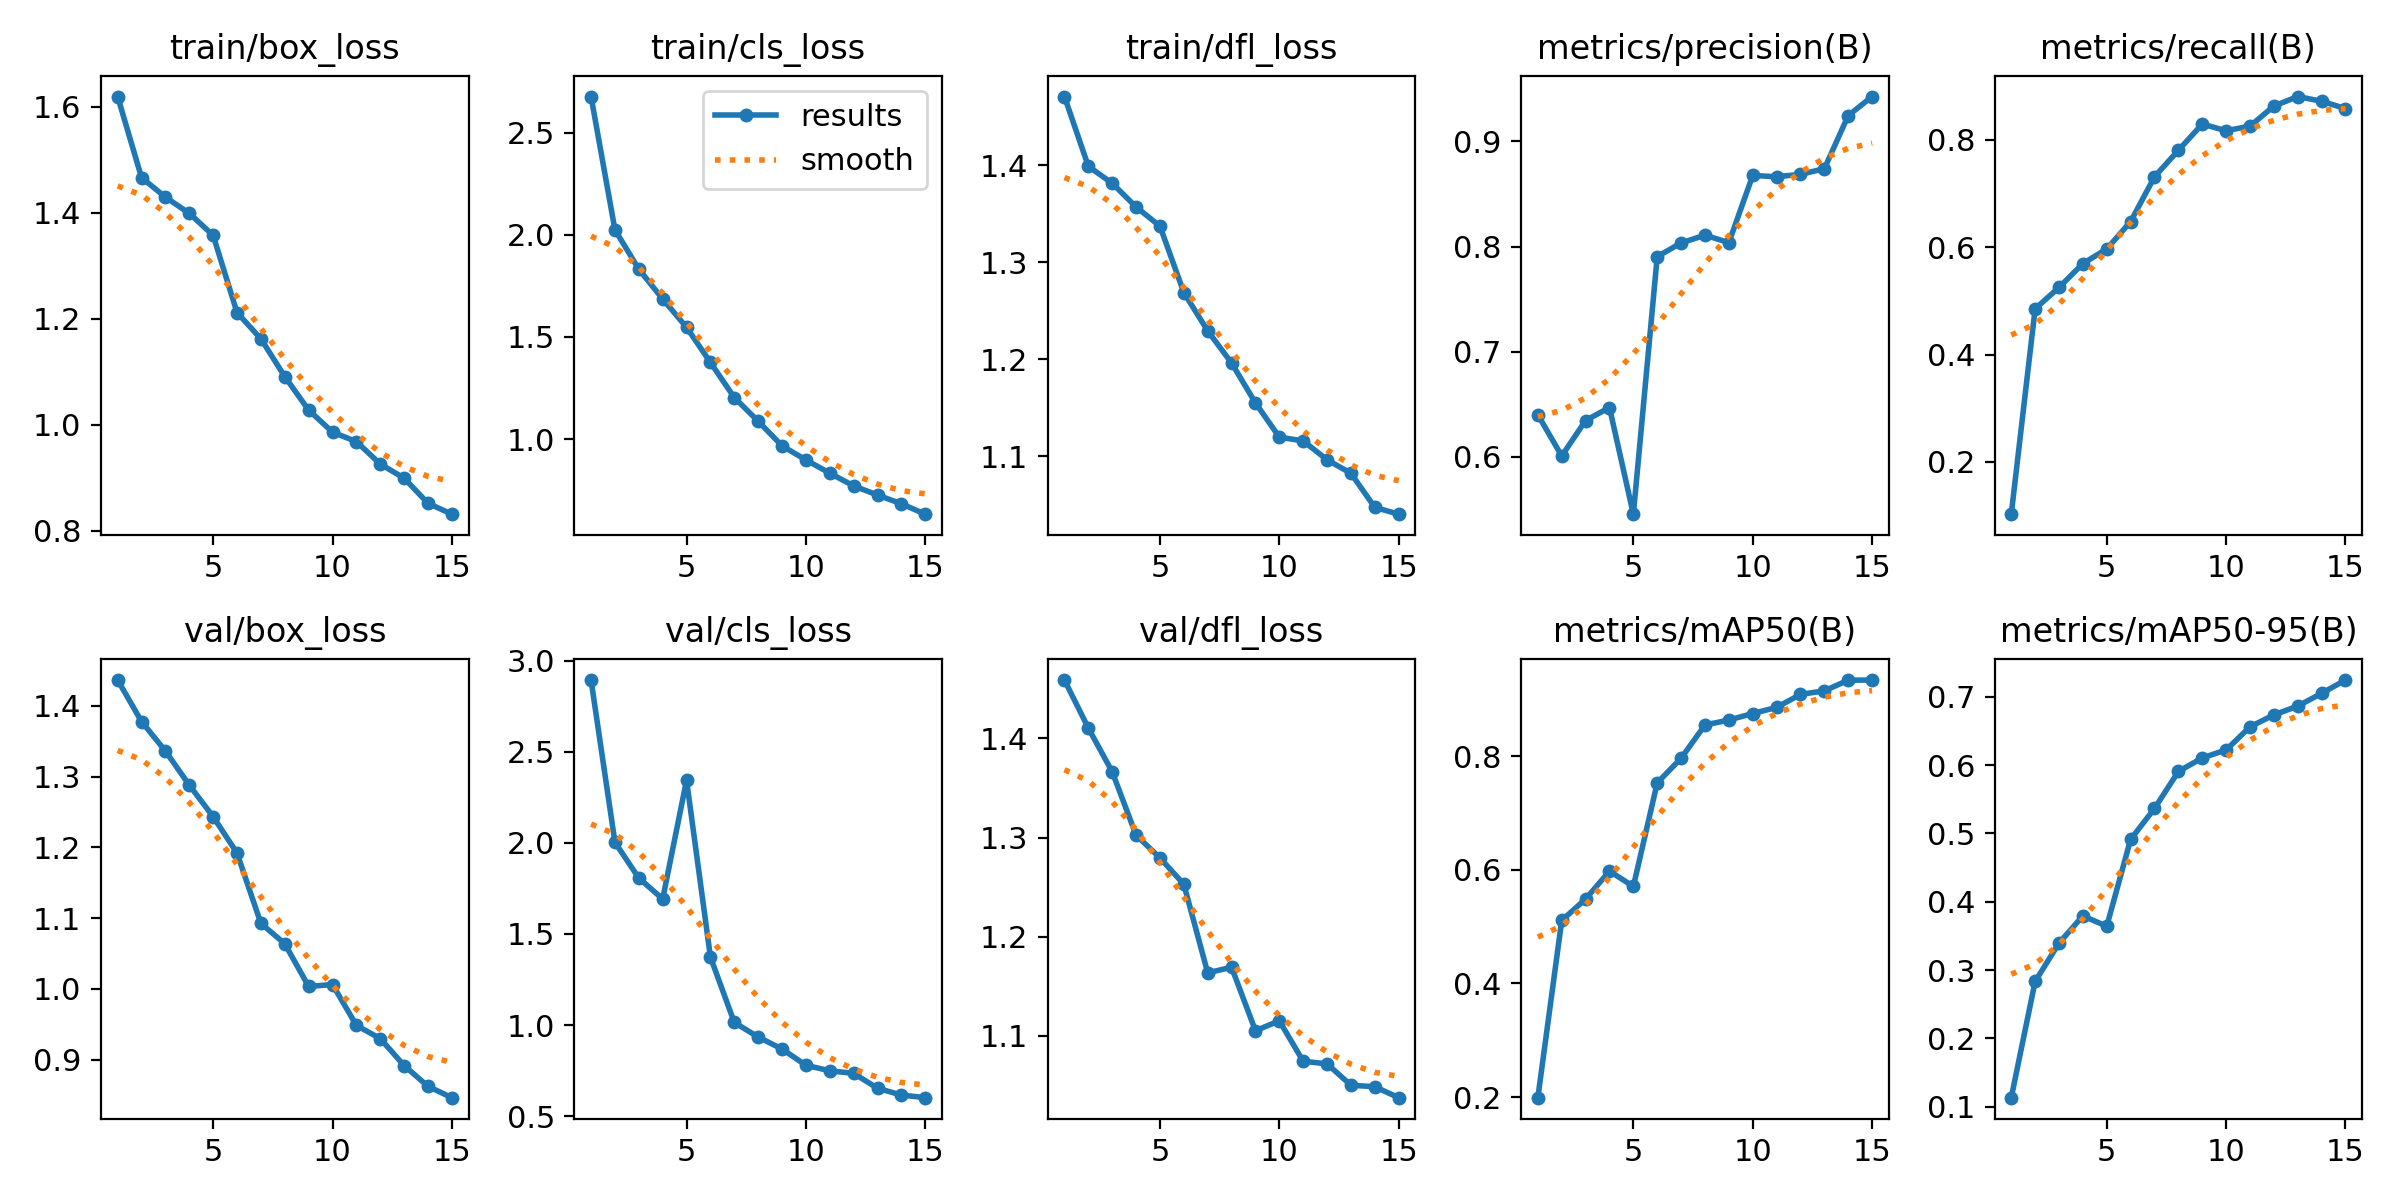

In [12]:
Image(f'{HOME}/runs/detect/train-Detect-Accident-Non-Accident-2/results.png', width=800)

## Validação e Teste

In [14]:
# Iremos utilizar o modelo com o melhor desempenho durante o treinamento
model = YOLO('runs/detect/train/Detect-Accident.pt')

In [ ]:
results_val = model.val(
    data=f'{dataset.location}/data.yaml',
    imgsz=640,
    batch=8,
    conf=0.001,
    split='test'
)

Ultralytics YOLOv8.2.43 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3006038 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/drive/MyDrive/Car-Accident-Severity-1/test/labels... 333 images, 0 backgrounds, 0 corrupt: 100%|██████████| 333/333 [00:03<00:00, 86.88it/s] 


val: New cache created: /content/drive/MyDrive/Car-Accident-Severity-1/test/labels.cache


os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 42/42 [00:10<00:00,  4.17it/s]


                   all        333        350      0.996      0.952      0.982      0.912
     accident moderate         73         73      0.999      0.932       0.97      0.896
       accident severe        262        277      0.993      0.973      0.994      0.928
Speed: 0.5ms preprocess, 8.6ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to runs/detect/val


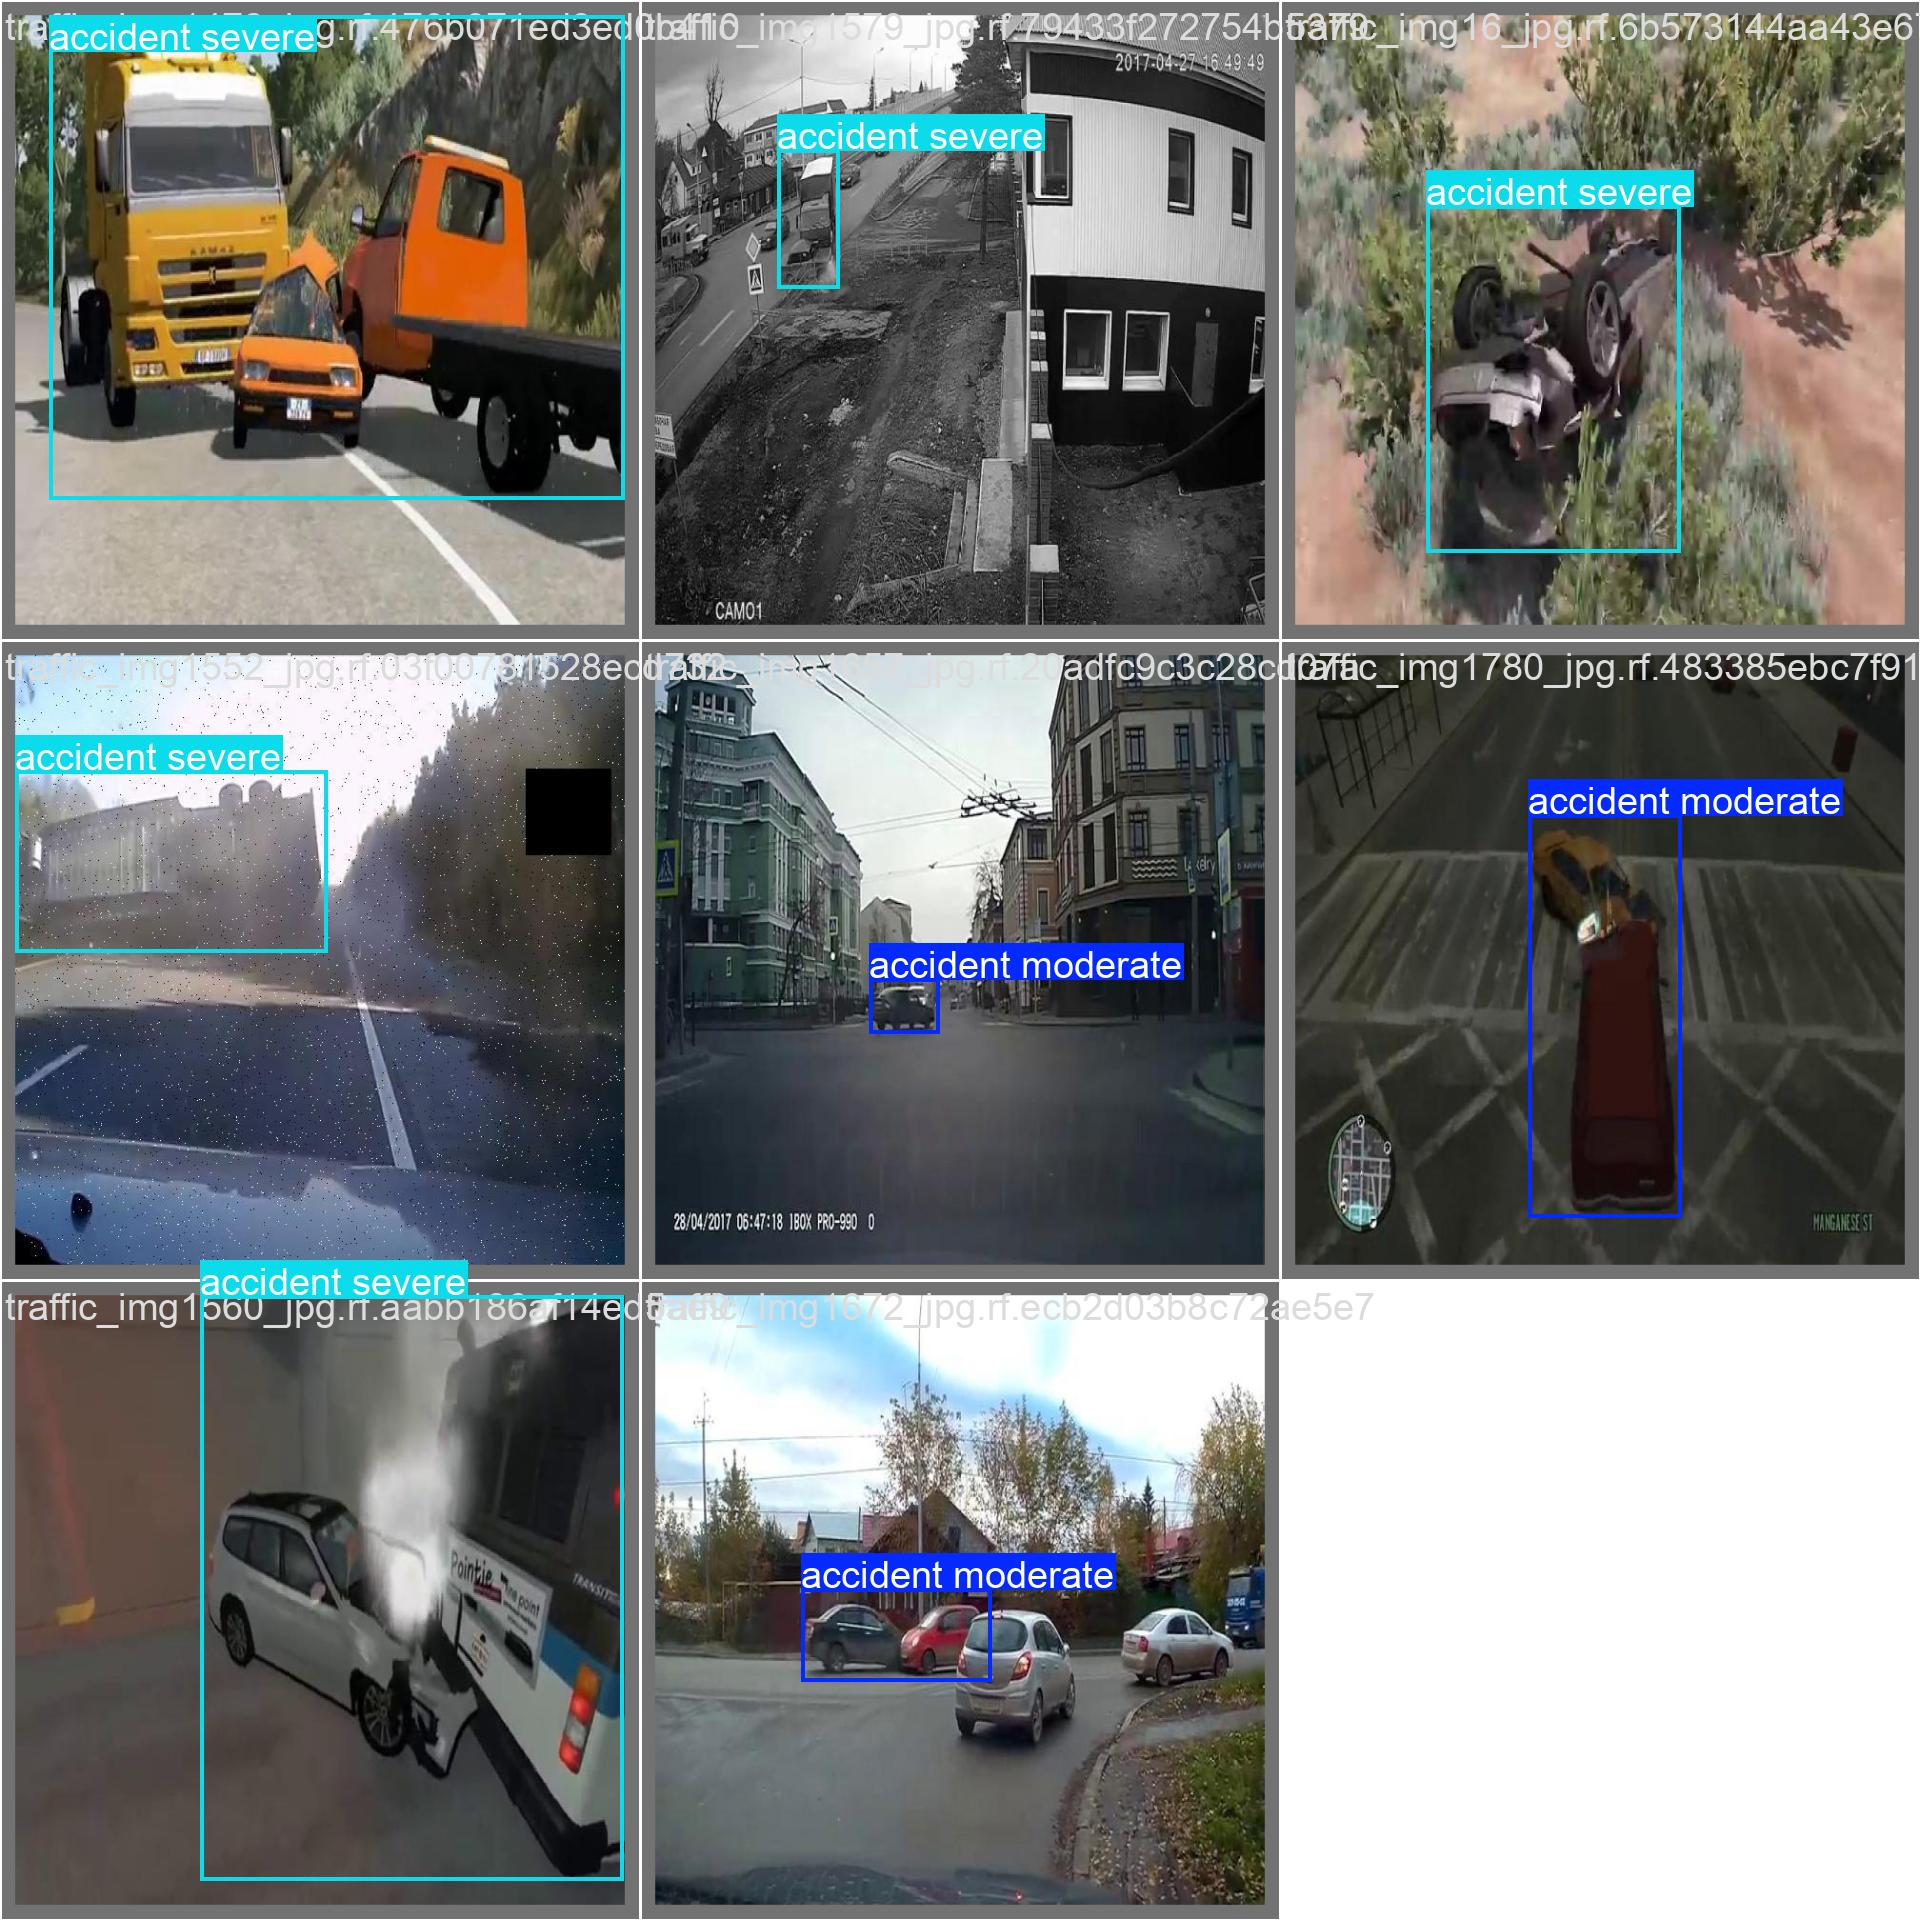

In [7]:
Image(f'{HOME}/runs/detect/val-Detect-Accident/val_batch2_labels.jpg', width=640)

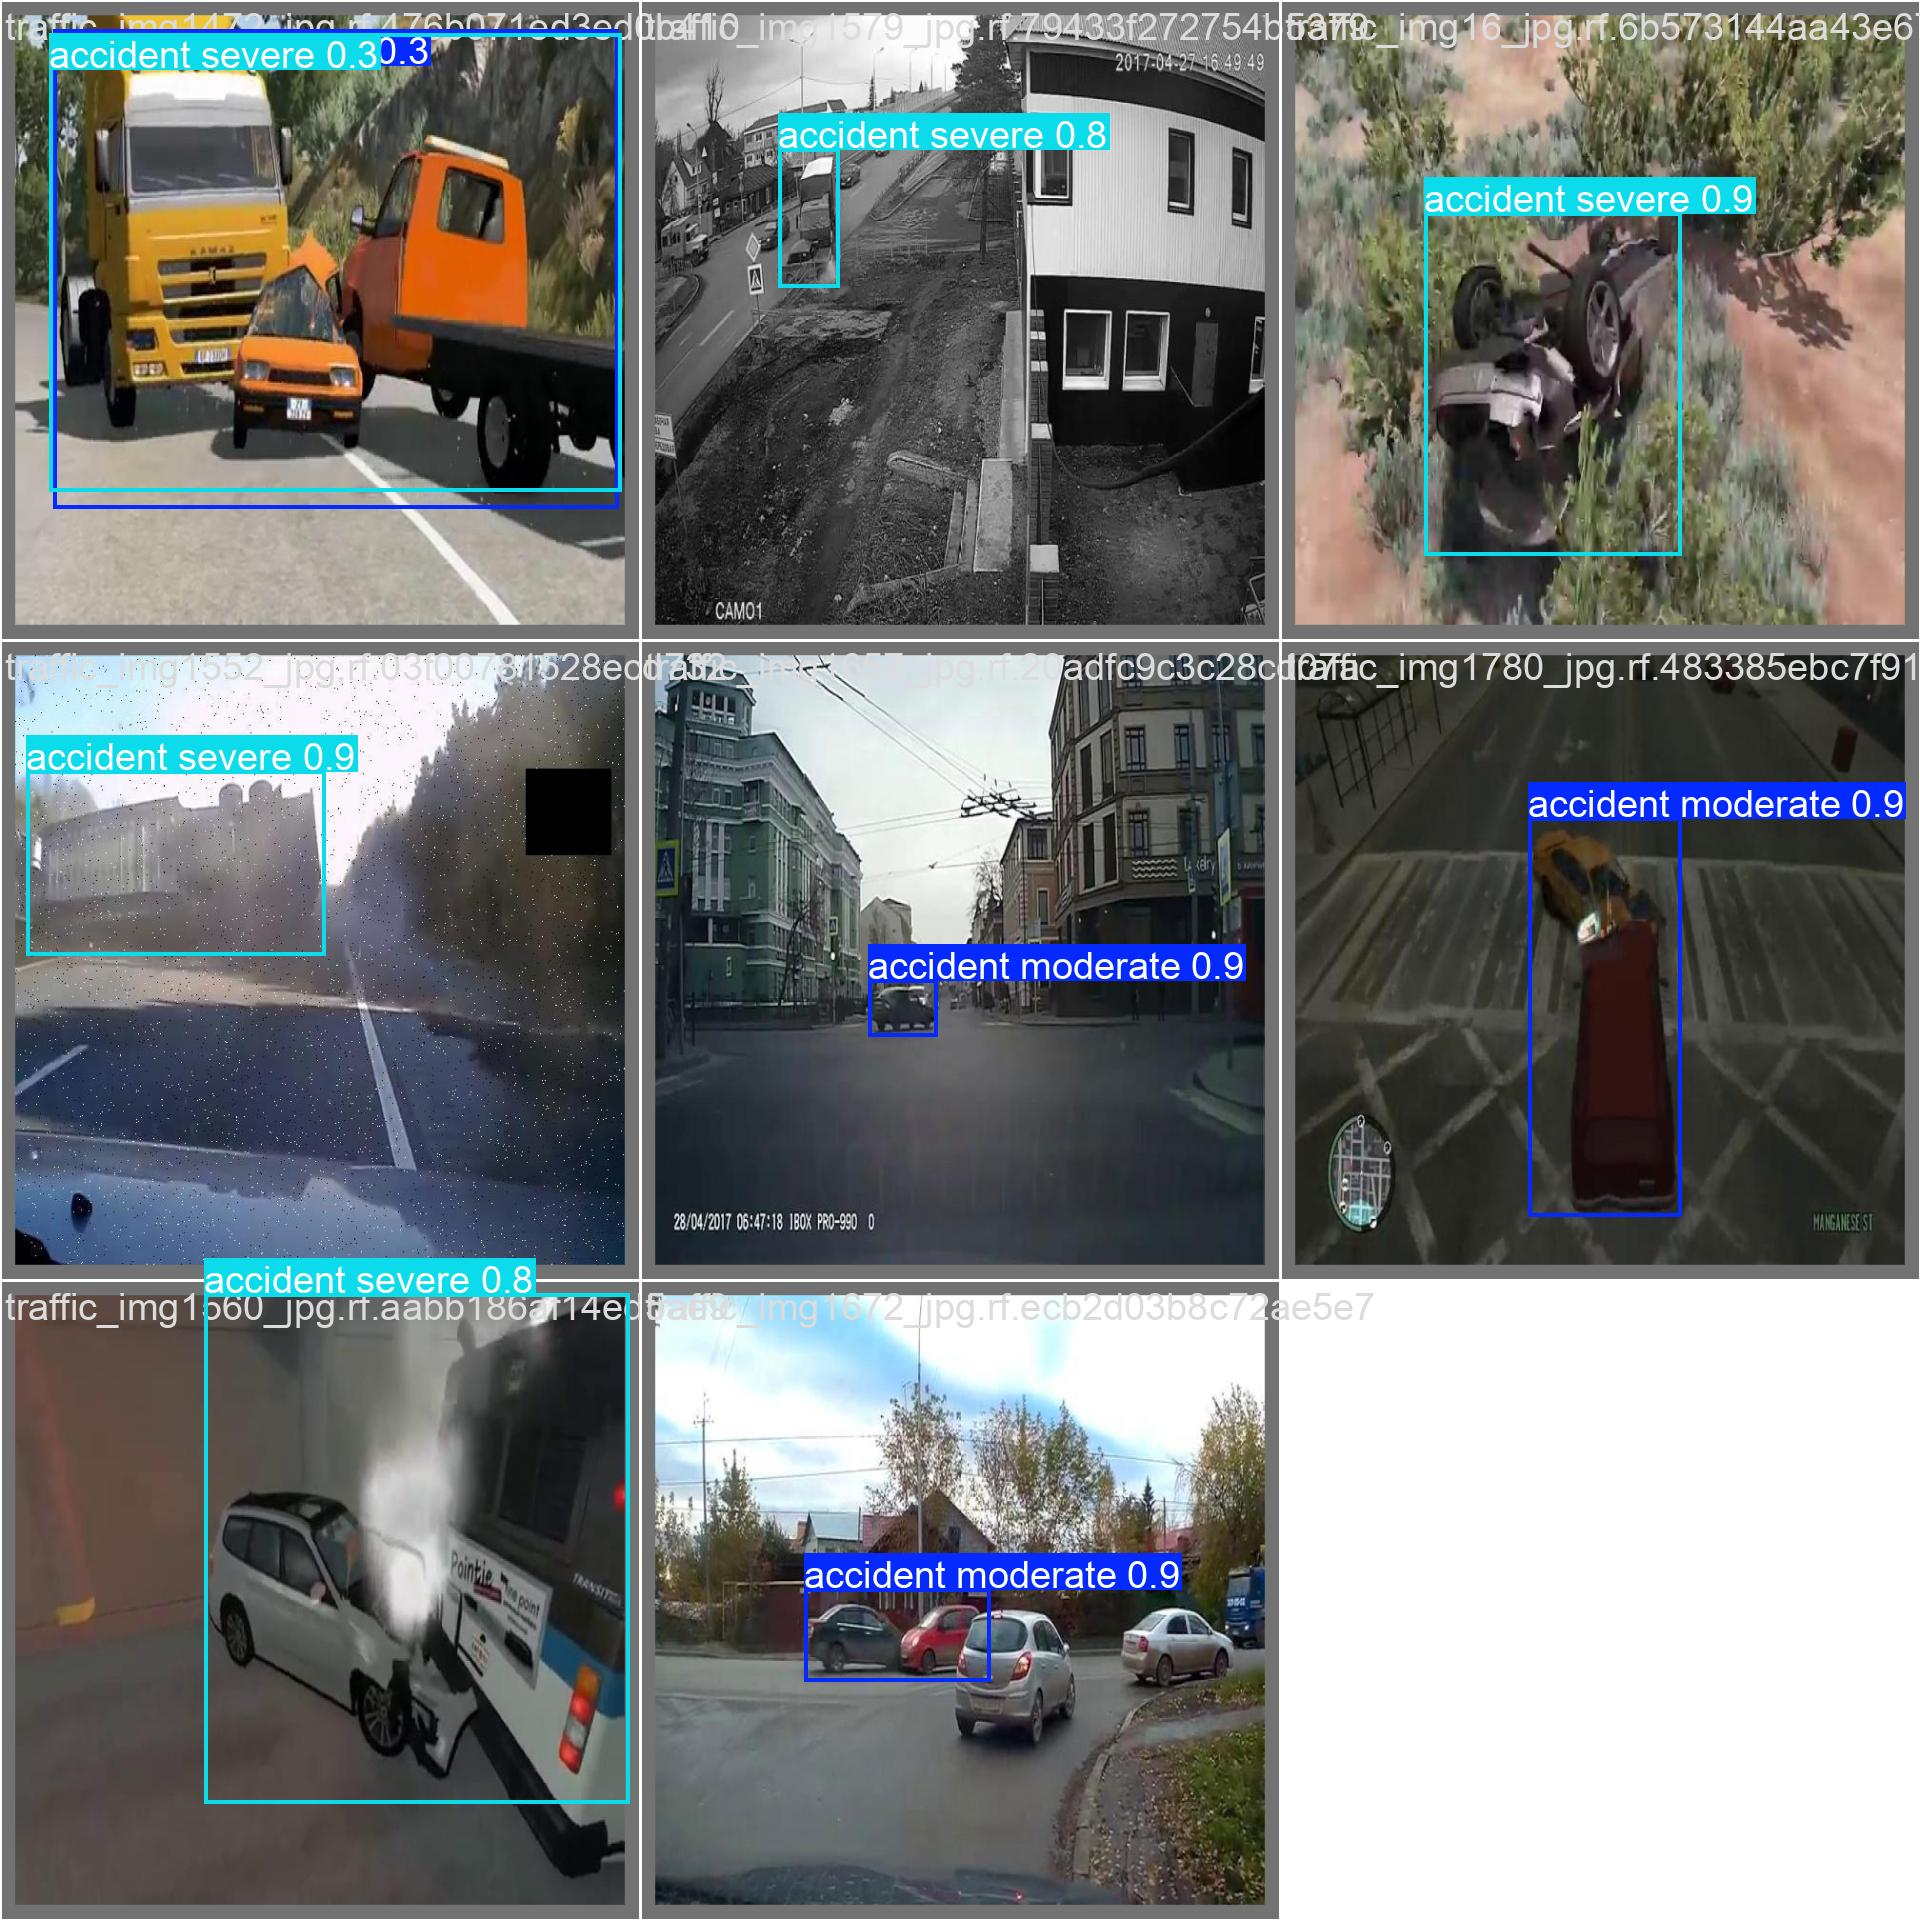

In [8]:
Image(f'{HOME}/runs/detect/val-Detect-Accident/val_batch2_pred.jpg', width=640)

### Inferência
- Vamos utilizar o modelo de melhor desempenho em vídeos e imagens reais

In [1]:
import cv2 as cv
from ultralytics import YOLO
import random
import pandas as pd
from datetime import datetime

In [6]:
print(model.model.names.values())

dict_values(['Accident', 'Non Accident'])


In [3]:
MODEL_SOURCE_PATH = r'runs\detect\train\Detect-Accident-Non-Accident.pt'
VIDEO_SOURCE_PATH = 'files\Video1.mp4' # WEB CAM = 0

# Definindo a largura e a altura dos frames
LARGURA_FRAME = 640
ALTURA_FRAME = 480

LIMIAR_CONFIANCA = 0.7 # Limiar de confiança

# Se SKIP_FRAMES for 2, a cada 2 frames será processado
SKIP_FRAMES = 2
frame_count = 0

In [5]:
# Carregando o modelo pré-treinado YOLOv8n
model = YOLO(MODEL_SOURCE_PATH)

# Obtendo o nome de todas as classes do modelo
lista_classes = list(model.model.names.values())

# Obtendo o número máximo de classes detectadas pelo modelo
num_classes = len(model.model.names)

# Vamos gerar cores aleatórias para as classes
cores_deteccao = []
for i in range(num_classes):
    r = random.randint(0, 255)
    g = random.randint(0, 255)
    b = random.randint(0, 255)
    cores_deteccao.append((b, g, r))

In [8]:
print(lista_classes)

['Accident', 'Non Accident']


In [11]:
# Inicializar DataFrame para armazenar os resultados
df = pd.DataFrame(columns=['local', 'horario', 'frame', 'classe', 'confiança'])

def process_video(source_path: str | int = 0) -> None:
    global frame_count, df

    # Carregando o vídeo
    cap = cv.VideoCapture(source_path)

    while cap.isOpened():
        # Capturando frame a frame
        ret, frame = cap.read()

        if not ret:
            print("FIM!")
            break

        frame_count += 1
        if frame_count % SKIP_FRAMES != 0:
            continue

        # Redimensionando o frame
        frame = cv.resize(frame, (LARGURA_FRAME, ALTURA_FRAME))

        # Realizando a detecção de objetos no frame
        deteccoes = model.track(source=[frame], conf=LIMIAR_CONFIANCA, save=False, iou=0.70, imgsz=640, classes=0)

        # Convertendo a saída do modelo para um numpy array
        if len(deteccoes) != 0:
            for deteccao in deteccoes:
                caixas = deteccao.boxes
                for caixa in caixas:
                    id_classe = int(caixa.cls[0])
                    confianca = float(caixa.conf[0])
                    bb = caixa.xyxy[0]

                    # Desenhando uma caixa delimitadora ao redor do objeto detectado
                    cv.rectangle(frame,
                                (int(bb[0]), int(bb[1])),
                                (int(bb[2]), int(bb[3])),
                                cores_deteccao[id_classe],
                                3)
                    
                    # Exibindo o nome da classe e a confiança da detecção
                    fonte = cv.FONT_HERSHEY_COMPLEX
                    cv.putText(
                        frame,
                        lista_classes[int(id_classe)]
                        + " "
                        + str(round(confianca, 3))
                        + "%",
                        (int(bb[0]), int(bb[1]) - 10),
                        fonte,
                        1,
                        (255, 255, 255),
                        2,
                    )
                    
                    # Adicionando os resultados ao DataFrame usando concat
                    new_row = pd.DataFrame([{
                        'local': 'Rua X, Setor Y, Cidade Z',
                        'horario': datetime.now(),
                        'frame': frame_count,
                        'classe': lista_classes[int(id_classe)],
                        'confiança': confianca,
                    }])
                    df = pd.concat([df, new_row], ignore_index=True)

        # Exibindo o frame resultante
        cv.imshow('Detecção de Objetos', frame)

        # Terminando a execução quando "Q" é pressionado
        if cv.waitKey(1) == ord('q'):
            break

    cap.release() # Libera a captura de vídeo
    cv.destroyAllWindows() # Fecha todas as janelas

In [12]:
# Executar video de demonstração
process_video(source_path=VIDEO_SOURCE_PATH)


0: 480x640 (no detections), 150.0ms
Speed: 3.0ms preprocess, 150.0ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 172.0ms
Speed: 3.0ms preprocess, 172.0ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 154.5ms
Speed: 2.0ms preprocess, 154.5ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 158.0ms
Speed: 2.0ms preprocess, 158.0ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 138.0ms
Speed: 2.0ms preprocess, 138.0ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 141.5ms
Speed: 2.0ms preprocess, 141.5ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 140.0ms
Speed: 2.0ms preprocess, 140.0ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 132.0ms
Speed: 2.0ms prepr

C:\Users\samue\AppData\Local\Temp\ipykernel_25868\1714770356.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


Speed: 2.0ms preprocess, 131.0ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Accident, 142.5ms
Speed: 2.0ms preprocess, 142.5ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Accident, 145.5ms
Speed: 1.0ms preprocess, 145.5ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Accident, 127.6ms
Speed: 2.0ms preprocess, 127.6ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Accident, 128.5ms
Speed: 2.0ms preprocess, 128.5ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Accident, 128.0ms
Speed: 2.0ms preprocess, 128.0ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Accident, 137.0ms
Speed: 2.0ms preprocess, 137.0ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 Accident, 123.5ms
Speed: 1.0ms preprocess, 123.5ms inference, 1.0ms postprocess per image at shape (1, 3, 48

In [13]:
display(df)

,local,horario,frame,classe,confiança
0,"Rua X, Setor Y, Cidade Z",2024-07-02 11:09:43.996617,320,Accident,0.844579
1,"Rua X, Setor Y, Cidade Z",2024-07-02 11:09:44.177616,322,Accident,0.894685
2,"Rua X, Setor Y, Cidade Z",2024-07-02 11:09:44.379133,324,Accident,0.901509
3,"Rua X, Setor Y, Cidade Z",2024-07-02 11:09:44.572657,326,Accident,0.895067
4,"Rua X, Setor Y, Cidade Z",2024-07-02 11:09:44.763217,328,Accident,0.898906
...,...,...,...,...,...
71,"Rua X, Setor Y, Cidade Z",2024-07-02 11:09:57.242723,462,Accident,0.871235
72,"Rua X, Setor Y, Cidade Z",2024-07-02 11:09:57.504778,464,Accident,0.868946
73,"Rua X, Setor Y, Cidade Z",2024-07-02 11:09:57.742815,466,Accident,0.837628
74,"Rua X, Setor Y, Cidade Z",2024-07-02 11:09:57.960337,468,Accident,0.805152


In [14]:
# Salvar o DataFrame em um arquivo CSV após processar o vídeo
df.to_csv('output_results.csv', index=False)

### Limitações e como foram contornadas:
- Datasets de qualidade ---> Elaboração de um dataset próprio

- Dificuldade em diferenciar sobreposição de carros de acidentes ---> Treinamento com o que não é um acidente

- Limitação de recursos ---> Modelo NANO foi utilizado e apresenta bons resultados mas evoluindo ao LARGE tende a excelência

- Como o esperado, o YOLO tem dificuldades com imagens distantes ---> Ajuste de câmeras no caso de uso real

- Dificuldade para extender o YOLOv8 sem afetar as classes pré-treinadas do modelo